# Chapter 160 — Systems of Linear Equations

> **Prerequisites:** Matrix multiplication *(ch154)*, matrix inverse *(ch157)*
> **You will learn:**
> - How Ax=b encodes a system of equations
> - Three cases: unique solution, no solution, infinite solutions
> - Geometric interpretation: intersection of hyperplanes
> - Row echelon form and rank conditions
>
> **Environment:** Python 3.x, numpy, matplotlib

Unique solution: rank(A)=2 = n=2
No solution (inconsistent): rank(A)=1 < rank([A|b])=2
Infinite solutions: rank(A)=1 < n=2, 1 free variables
Infinite solutions: rank(A)=2 < n=3, 1 free variables


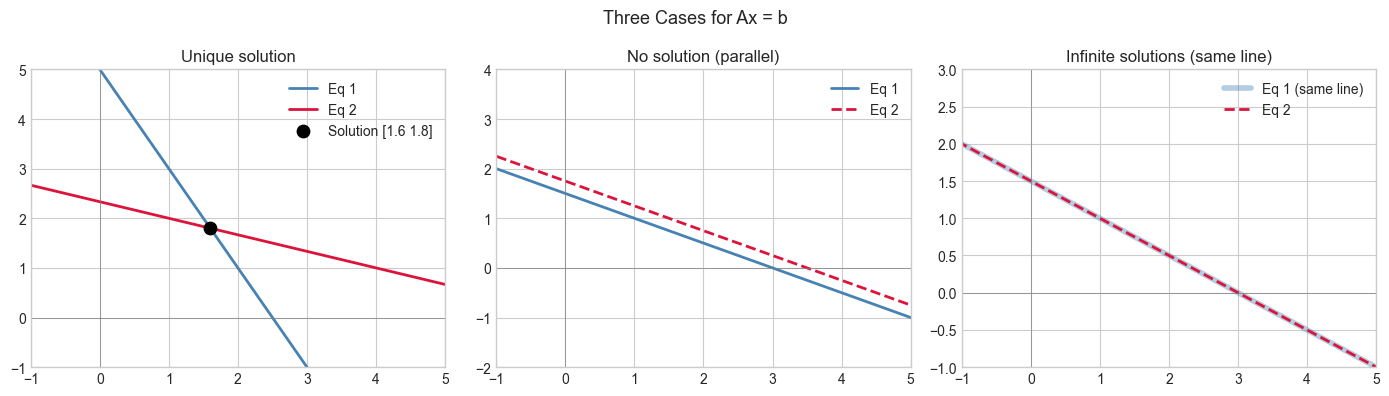

In [1]:
# --- Systems of Linear Equations: Three cases ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def classify_system(A, b):
    """
    Classify Ax=b: unique, no solution, or infinite solutions.

    Args:
        A: 2D array (m, n)
        b: 1D array (m,)

    Returns:
        string classification
    """
    m, n = A.shape
    rank_A = np.linalg.matrix_rank(A)
    # Augmented matrix [A | b]
    Ab = np.column_stack([A, b])
    rank_Ab = np.linalg.matrix_rank(Ab)
    if rank_A < rank_Ab:
        return f"No solution (inconsistent): rank(A)={rank_A} < rank([A|b])={rank_Ab}"
    elif rank_A == n:
        return f"Unique solution: rank(A)={rank_A} = n={n}"
    else:
        return f"Infinite solutions: rank(A)={rank_A} < n={n}, {n-rank_A} free variables"

# Test cases
cases = [
    (np.array([[2.,1.],[1.,3.]]), np.array([5., 7.])),           # unique
    (np.array([[1.,2.],[2.,4.]]), np.array([3., 7.])),           # no solution
    (np.array([[1.,2.],[2.,4.]]), np.array([3., 6.])),           # infinite
    (np.array([[1.,0.,1.],[0.,1.,1.],[1.,1.,2.]]), np.array([1.,2.,3.])),  # infinite 3D
]
for A, b in cases:
    print(classify_system(A, b))

# 2D visualization: lines as rows of Ax = b
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
x = np.linspace(-2, 6, 300)

# Unique: two lines intersecting
A1 = np.array([[2.,1.],[1.,3.]]); b1 = np.array([5.,7.])
sol = np.linalg.solve(A1, b1)
axes[0].plot(x, (b1[0]-A1[0,0]*x)/A1[0,1], 'steelblue', lw=2, label='Eq 1')
axes[0].plot(x, (b1[1]-A1[1,0]*x)/A1[1,1], 'crimson', lw=2, label='Eq 2')
axes[0].scatter(*sol, color='black', zorder=5, s=80, label=f'Solution {sol.round(2)}')
axes[0].set_xlim(-1,5); axes[0].set_ylim(-1,5); axes[0].legend(); axes[0].set_title('Unique solution')

# No solution: parallel lines
A2 = np.array([[1.,2.],[2.,4.]]); b2 = np.array([3.,7.])
axes[1].plot(x, (b2[0]-A2[0,0]*x)/A2[0,1], 'steelblue', lw=2, label='Eq 1')
axes[1].plot(x, (b2[1]-A2[1,0]*x)/A2[1,1], 'crimson', lw=2, linestyle='--', label='Eq 2')
axes[1].set_xlim(-1,5); axes[1].set_ylim(-2,4); axes[1].legend(); axes[1].set_title('No solution (parallel)')

# Infinite: same line
A3 = np.array([[1.,2.],[2.,4.]]); b3 = np.array([3.,6.])
axes[2].plot(x, (b3[0]-A3[0,0]*x)/A3[0,1], 'steelblue', lw=4, alpha=0.4, label='Eq 1 (same line)')
axes[2].plot(x, (b3[1]-A3[1,0]*x)/A3[1,1], 'crimson', lw=2, linestyle='--', label='Eq 2')
axes[2].set_xlim(-1,5); axes[2].set_ylim(-1,3); axes[2].legend(); axes[2].set_title('Infinite solutions (same line)')

for ax in axes: ax.axhline(0,color='gray',lw=0.5); ax.axvline(0,color='gray',lw=0.5)
plt.suptitle('Three Cases for Ax = b', fontsize=13); plt.tight_layout(); plt.show()

---

## 4. Mathematical Formulation

```
System of m equations in n unknowns:
  a₁₁x₁ + a₁₂x₂ + ... + a₁ₙxₙ = b₁
  a₂₁x₁ + a₂₂x₂ + ... + a₂ₙxₙ = b₂
  ...
  aₘ₁x₁ + aₘ₂x₂ + ... + aₘₙxₙ = bₘ

Written as: Ax = b

Solvability (Rouché-Capelli theorem):
  rank(A) < rank([A|b]) → no solution
  rank(A) = rank([A|b]) = n → unique solution
  rank(A) = rank([A|b]) < n → infinite solutions (family of dimension n - rank(A))
```

---

## 7. Exercises

**Easy 1.** Write the system 2x+y=5, 3x-y=10 as a matrix equation Ax=b. Solve by hand.

**Easy 2.** What does it mean geometrically if a 3×3 system has infinite solutions?

**Medium 1.** Use `classify_system` to explore: for what values of k does `[[k,1],[2,3]]x = [4,6]` have (a) a unique solution, (b) no solution, (c) infinite solutions?

**Medium 2.** Solve a 5×5 random system 100 times and record the condition number. What does a high condition number mean for numerical accuracy of the solution?

**Hard.** Implement `null_space(A)` that returns a basis for the null space of A (all x such that Ax=0). Use SVD: the null space basis is the right singular vectors corresponding to singular values ≈ 0.

---

## 9. Chapter Summary & Connections

- `Ax=b` has: (1) unique solution if rank(A)=n; (2) no solution if rank inconsistency; (3) ∞ solutions if rank(A)<n.
- Geometrically: each equation is a hyperplane; the solution is their intersection.

**Forward connections:**
- In ch161 (Gaussian Elimination), we compute the solution systematically.
- In ch168 (Projection Matrices), the case 'no exact solution' leads to least-squares via orthogonal projection.